In [ ]:
# Mulaudzi A 4088375
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Mulaudzi A 4088375
N1 = np.random.randint(1, 11) * 100
N2 = np.random.randint(1, 11) * 100
N3 = np.random.randint(1, 11) * 100

sigma1 = [666.67, 0.33]
sigma2 = [500, 0.25]
sigma3 = [500, 0.25]

x1_center = np.array([10000, 8.0])
x2_center = np.array([6500, 6.75])
x3_center = np.array([3500, 5.75])


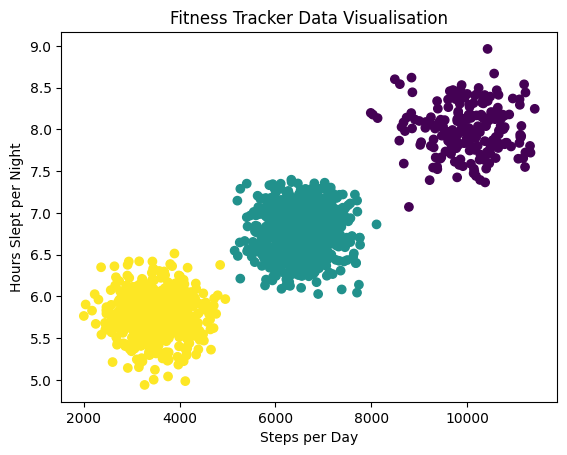

In [ ]:
# Mulaudzi A 4088375
X_T = np.vstack((x1_center, x2_center, x3_center))

noise1 = np.random.normal(scale=sigma1, size=(N1, 2))
noise2 = np.random.normal(scale=sigma2, size=(N2, 2))
noise3 = np.random.normal(scale=sigma3, size=(N3, 2))

X1 = X_T[0, :] + noise1
X2 = X_T[1, :] + noise2
X3 = X_T[2, :] + noise3

X = np.concatenate((X1, X2, X3), axis=0)
y = np.array([0] * N1 + [1] * N2 + [2] * N3)

# Mulaudzi A 4088375
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.xlabel("Steps per Day")
plt.ylabel("Hours Slept per Night")
plt.title("Fitness Tracker Data Visualisation")
plt.show()

Accuracy: 0.998125
Cluster 0 (Active):
  Average Steps per Day:         3485.96
  Average Hours Slept per Night: 5.76
Cluster 1 (Moderately Active):
  Average Steps per Day:         6529.64
  Average Hours Slept per Night: 6.76
Cluster 2 (Least Active):
  Average Steps per Day:         10049.53
  Average Hours Slept per Night: 8.00


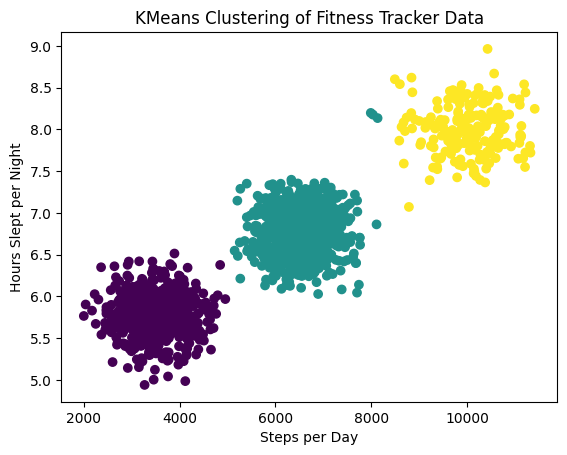

In [ ]:
# Mulaudzi A 4088375
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters)
kmeans.fit(X)
kmeans_labels = kmeans.labels_

aligned_labels = np.zeros_like(kmeans_labels)
for cluster in range(n_clusters):
    mask = (kmeans_labels == cluster)
    aligned_labels[mask] = np.argmax(np.bincount(y[mask]))

accuracy = np.sum(aligned_labels == y) / len(y)
print("Accuracy:", accuracy)

# Mulaudzi A 4088375
cluster_names = {0: "Active", 1: "Moderately Active", 2: "Least Active"}
for cluster in range(n_clusters):
    mask = (kmeans_labels == cluster)
    avg_steps = np.mean(X[mask, 0])
    avg_sleep = np.mean(X[mask, 1])
    print(f"Cluster {cluster} ({cluster_names[cluster]}):")
    print(f"  Average Steps per Day:         {avg_steps:.2f}")
    print(f"  Average Hours Slept per Night: {avg_sleep:.2f}")

# Mulaudzi A 4088375
plt.scatter(X[:, 0], X[:, 1], c=kmeans_labels)
plt.xlabel("Steps per Day")
plt.ylabel("Hours Slept per Night")
plt.title("KMeans Clustering of Fitness Tracker Data")
plt.show()